# Crop Yield Prediction for Food Security in Africa.

## 1.Business Understanding

### 1.1 Project Overview 

Agriculture plays an important role in providing food and supporting the economy in many African countries. However, many farmers find it difficult to estimate how much crop they will harvest before planting, and this can in turn lead to poor planning, low productivity, and financial losses.

The aim of this project is to build a machine learning system that predicts crop yield using soil information such as pH, nitrogen, phosphorus, potassium, soil moisture, and field size. This will help farmers make better farming decisions and improve food security.

### 1.2 Stakeholders.
##### The key statekeholders for this project are:
* Farmers and Farmer groups.
* Government Institutions.
* NGOs and development partners.
* Farm inputs providers and suppliers.
* Market Actors.
* Research Institutions and Academia.
* Food Security and Warning bodies.
* Financial Institutions & insurers.
* Consumers.

### 1.3 Business Problem
Food insecurity remains a major challenge in many African countries. Farmers often make planting decisions without knowing how much they are likely to harvest. This can lead to poor planning, inefficient use of fertilizers and other resources, and lower crop production. As a result, farmers may experience financial losses, while governments and agricultural organizations find it difficult to plan for future food needs. Thus creating a need for a a reliable system that can help predict crop yield before planting using soil data.

### 1.4 Objectives
* Develop a machine learning model that can accurately predict crop yield based on soil health indicators and field characteristics.

* Help farmers make informed farming decisions by predicting the expected yield of their selected crop before planting.

* Provide insights that can support farmers, agricultural organizations, and governments in improving agricultural productivity and food security.

## 2. Data Understanding

### 2.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### 2.2 Load Data

In [2]:
# load data
df = pd.read_excel('../data/Editted2.xlsx')
df_copy = df.copy()
df.head()

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
0,coffee (green beans),6400,1.00,5.5,25.9,1.9,2.0,3.8,17.4,605.0,325.0
1,coffee (green beans),2000,0.75,5.6,29.4,2.2,7.0,4.4,18.8,440.0,245.0
2,potato,35000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
3,cabbage,60000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
4,peas,4500,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0


### 2.3 Data Exploration

In [3]:
print(df.columns)

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture', 'Organic Matter Need',
       'Lime Need'],
      dtype='object')


In [4]:
print(df.shape)

(13802, 11)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13802 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13802 non-null  object 
 1   Target Yield         13802 non-null  int64  
 2   Field Size           13802 non-null  float64
 3   pH (water)           13776 non-null  float64
 4   Organic Carbon       13768 non-null  float64
 5   Total Nitrogen       13768 non-null  float64
 6   Phosphorus (M3)      13773 non-null  float64
 7   Potassium (exch.)    13773 non-null  float64
 8   Soil moisture        9655 non-null   float64
 9   Organic Matter Need  13768 non-null  float64
 10  Lime Need            13774 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.2+ MB
None


In [6]:
df_missing = df.isnull().sum()
df_missing

Crop Name                 0
Target Yield              0
Field Size                0
pH (water)               26
Organic Carbon           34
Total Nitrogen           34
Phosphorus (M3)          29
Potassium (exch.)        29
Soil moisture          4147
Organic Matter Need      34
Lime Need                28
dtype: int64

In [7]:
df_null = df.isnull().sum() / len(df) * 100
df_null

Crop Name               0.000000
Target Yield            0.000000
Field Size              0.000000
pH (water)              0.188378
Organic Carbon          0.246341
Total Nitrogen          0.246341
Phosphorus (M3)         0.210114
Potassium (exch.)       0.210114
Soil moisture          30.046370
Organic Matter Need     0.246341
Lime Need               0.202869
dtype: float64

In [8]:
df.describe()

,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
count,1.380200e+04,13802.000000,13776.000000,13768.000000,13768.000000,13773.000000,13773.000000,9655.000000,1.376800e+04,1.377400e+04
mean,2.388100e+04,123.463307,6.361474,25.417940,2.271426,12.879416,6.755718,15.568058,4.133714e+05,2.581598e+04
std,3.808466e+05,7185.915011,0.737447,22.254906,2.214835,14.399338,5.422551,8.045762,2.423067e+07,1.773352e+06
min,1.000000e+00,0.001000,4.490000,0.900000,0.100000,0.300000,0.300000,0.800000,0.000000e+00,0.000000e+00
25%,1.200000e+03,0.500000,5.800000,11.900000,1.100000,4.400000,3.000000,8.300000,3.050000e+02,5.000000e+01
50%,4.500000e+03,1.000000,6.380000,19.900000,1.800000,8.300000,5.100000,15.800000,7.800000e+02,1.550000e+02
75%,2.000000e+04,2.000000,6.890000,31.400000,2.700000,15.700000,9.000000,21.700000,1.630000e+03,3.200000e+02
max,4.111111e+07,589674.000000,8.460000,327.200000,24.900000,236.900000,43.400000,50.700000,2.007840e+09,1.468288e+08


In [9]:
# checking for dulicates

df.duplicated().sum()

np.int64(6)

In [10]:
# checking dulicate rows

dups = df[df.duplicated(keep=False)]
dups

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
4413,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
4434,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
12850,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12851,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12852,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12853,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
13705,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13711,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13736,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0
13737,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0


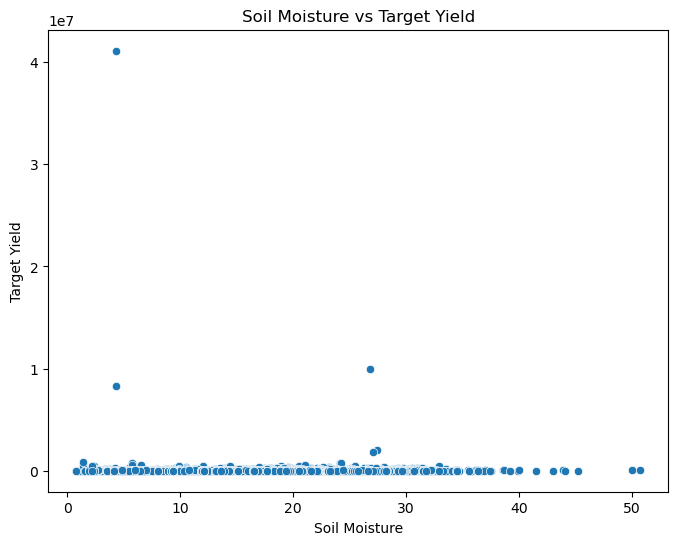

In [11]:
# Check for outliers
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Soil moisture",
    y="Target Yield"
)

plt.title("Soil Moisture vs Target Yield")
plt.xlabel("Soil Moisture")
plt.ylabel("Target Yield")

plt.show()

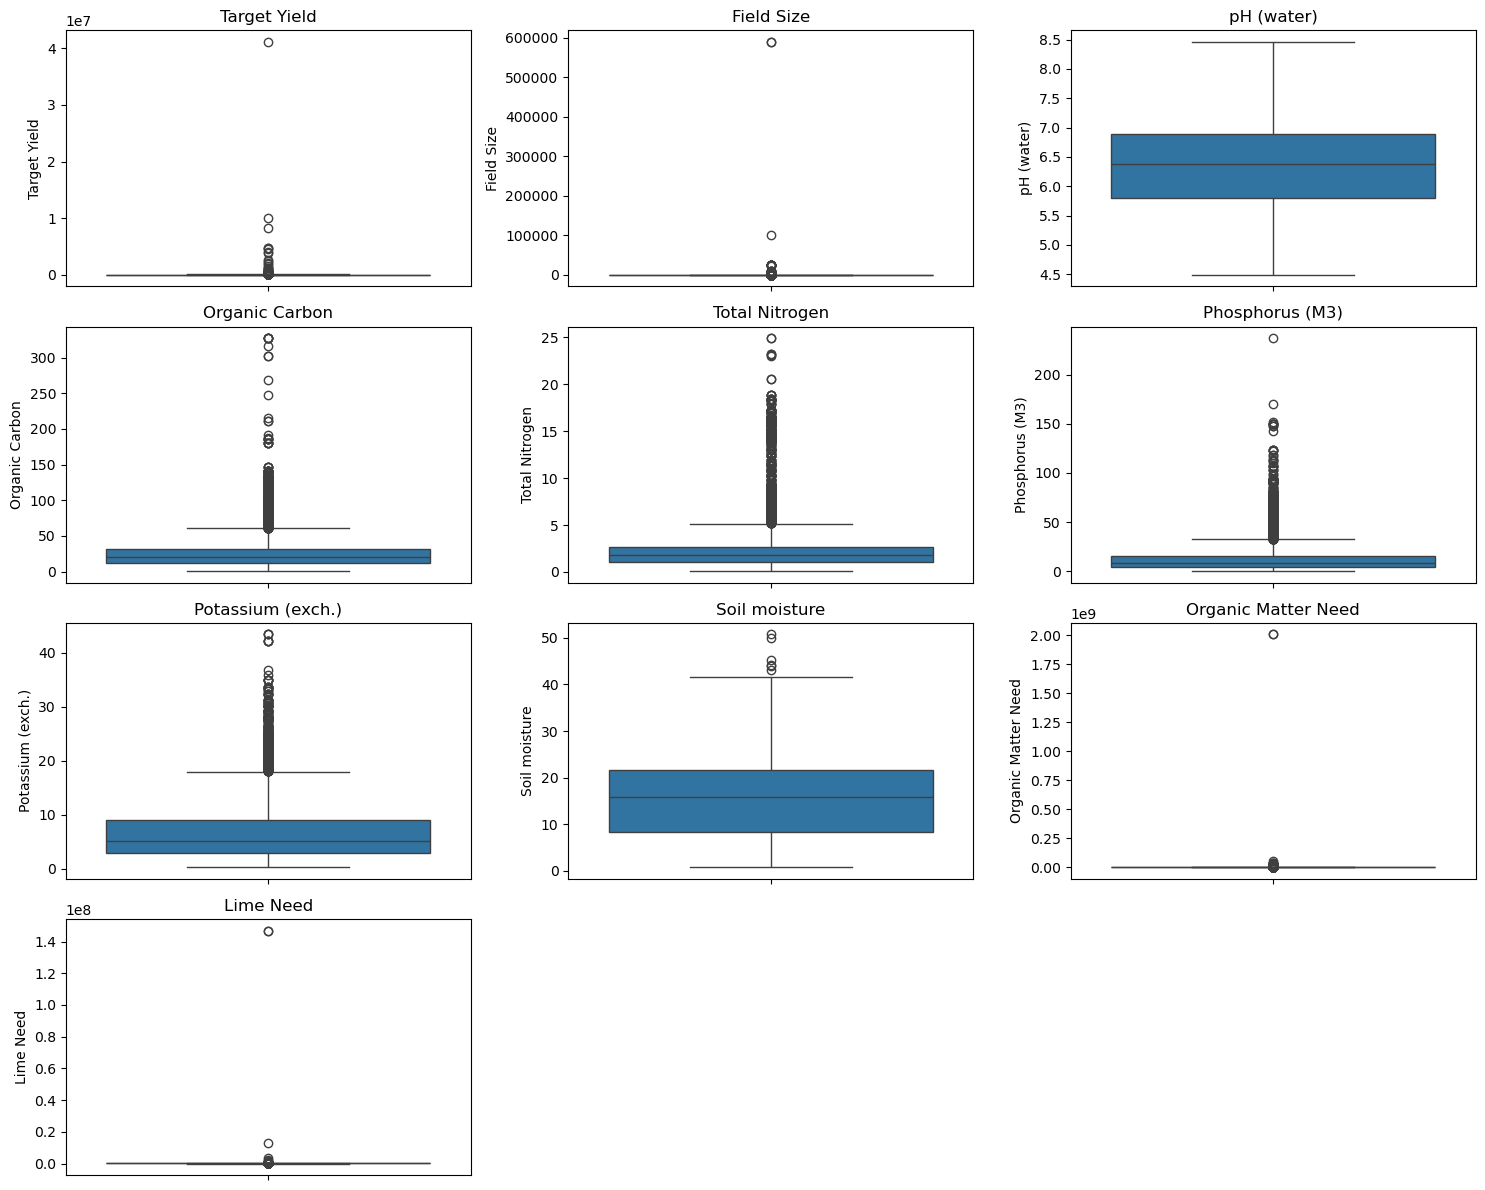

In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
# Top 20 rows by Target Yield

print(df.nlargest(20, 'Target Yield')[['Crop Name', 'Target Yield', 'Field Size']])

print()

                     Crop Name  Target Yield  Field Size
12192                     oats      41111111     3629.00
971       coffee (green beans)      10000000        8.00
12193                beet root       8333333     3629.00
7832             passion fruit       4800000      160.00
7834                    papaya       4800000      160.00
7789                field bean       4500000        2.50
7823                   cabbage       4000000      160.00
7824                    orange       3840000      160.00
7833                     onion       2560000      160.00
7825                  chillies       2400000      160.00
275       coffee (green beans)       2000000        0.25
296       coffee (green beans)       1850000        2.50
7796                     melon       1500000        0.25
9250   tree tomato (tamarillo)       1250000        7.00
7690             passion fruit       1200000        1.00
7795                    orange       1200000        0.25
13792                    vetch 

In [14]:
# Top 20 rows by Field Size

print(df.nlargest(20, 'Field Size')[['Crop Name', 'Target Yield', 'Field Size']])

            Crop Name  Target Yield  Field Size
12183         soybean          1542    589674.0
12184          grapes         13200    589674.0
12489         avocado        100000    100000.0
10151       sugarcane         80000     23950.0
10152       sugarcane         80000     23950.0
10153       sugarcane         80000     23950.0
10155       sugarcane         80000     23950.0
10163       sugarcane         80000     23950.0
10188       sugarcane         80000     23950.0
10192       sugarcane         80000     23950.0
10197       sugarcane         80000     23950.0
10203       sugarcane         80000     23950.0
10206       sugarcane         80000     23950.0
10207       sugarcane         80000     23950.0
12191     melon-water          8669     21133.0
943           cabbage         10000     10000.0
12188  linseed (flax)        555555      8655.0
12189       butternut         59999      8655.0
12190         tobacco          5653      8655.0
12195          stevia          6134     

In [15]:
# Here we will identify outliers using the IQR method

# Calculate IQR for Target Yield
yield_q1 = df["Target Yield"].quantile(0.25)
yield_q3 = df["Target Yield"].quantile(0.75)
yield_iqr = yield_q3 - yield_q1

yield_lower = yield_q1 - 1.5 * yield_iqr
yield_upper = yield_q3 + 1.5 * yield_iqr

# Calculate IQR for Field Size
field_q1 = df["Field Size"].quantile(0.25)
field_q3 = df["Field Size"].quantile(0.75)
field_iqr = field_q3 - field_q1

field_lower = field_q1 - 1.5 * field_iqr
field_upper = field_q3 + 1.5 * field_iqr

# Identify rows that are outliers in either Target Yield or Field Size
outlier_mask = (
    (df["Target Yield"] < yield_lower) |
    (df["Target Yield"] > yield_upper) |
    (df["Field Size"] < field_lower) |
    (df["Field Size"] > field_upper)
)

# Display outlier information before removing them
print("Rows to remove:", outlier_mask.sum())
print("Rows remaining:", len(df) - outlier_mask.sum())
print("Percentage removed:", round(outlier_mask.sum() / len(df) * 100, 2), "%")

Rows to remove: 1863
Rows remaining: 11939
Percentage removed: 13.5 %


In [16]:
for crop, group in df.groupby('Crop Name'):
    Q1 = group['Target Yield'].quantile(0.25)
    Q3 = group['Target Yield'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = group[
        (group['Target Yield'] < lower) |
        (group['Target Yield'] > upper)
    ]

    print(crop, len(outliers))

alfalfa-lucerne 1
apple 3
arabica juvenile 0
avocado 49
banana 19
barley 0
basil 0
beet root 1
broccoli 3
butternut 0
cabbage 27
carrot 14
cashew 16
cassava 4
cauliflower 0
chickpea 1
chillies 12
coffee (cherry) 11
coffee (green beans) 134
cowpea 32
cucumber 1
cut flowers 2
eggplant 2
field bean 57
finger millet 7
garlic 2
ginger 0
grapes 1
green beans (snap beans, french beans) 16
groundnut 23
immature oil palm 0
kale 28
kiwi 1
lentil 0
lettuce 0
linseed (flax) 1
macadamia 21
maize (corn) 150
maize-beans intercrop 47
mango 28
mature cacao 1
mature oil palm 0
melon 1
melon-water 12
millet 1
mint 0
mungbean 2
napier grass 16
nuts 0
oats 1
okra 1
onion 26
orange 10
papaya 6
passion fruit 8
peas 13
pigeonpea 3
pineapple 0
potato 23
pumpkin 3
pyrethrum 0
rapeseed (canola) 0
rhodes grass 11
rice 6
sorghum 6
soybean 12
spinach 9
stevia 1
strawberry 1
sugarcane 18
sunflower 35
sweet pepper 7
sweet potato 22
tea 4
thyme 2
timber (general) 1
tobacco 1
tomato 23
tree tomato (tamarillo) 6
vetch 0

In [17]:
for crop, group in df.groupby('Crop Name'):
    Q1 = group['Field Size'].quantile(0.25)
    Q3 = group['Field Size'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_ = group[
        (group['Field Size'] < lower) |
        (group['Field Size'] > upper)
    ]

    print(crop, len(outliers_))

alfalfa-lucerne 3
apple 5
arabica juvenile 0
avocado 28
banana 14
barley 2
basil 4
beet root 1
broccoli 3
butternut 1
cabbage 31
carrot 6
cashew 6
cassava 9
cauliflower 0
chickpea 1
chillies 7
coffee (cherry) 1
coffee (green beans) 198
cowpea 10
cucumber 4
cut flowers 1
eggplant 1
field bean 60
finger millet 5
garlic 4
ginger 1
grapes 3
green beans (snap beans, french beans) 9
groundnut 6
immature oil palm 0
kale 46
kiwi 1
lentil 0
lettuce 0
linseed (flax) 1
macadamia 8
maize (corn) 409
maize-beans intercrop 149
mango 13
mature cacao 0
mature oil palm 0
melon 3
melon-water 13
millet 0
mint 1
mungbean 2
napier grass 8
nuts 0
oats 1
okra 1
onion 33
orange 11
papaya 4
passion fruit 7
peas 1
pigeonpea 3
pineapple 1
potato 19
pumpkin 7
pyrethrum 1
rapeseed (canola) 0
rhodes grass 16
rice 5
sorghum 2
soybean 12
spinach 17
stevia 2
strawberry 2
sugarcane 14
sunflower 4
sweet pepper 7
sweet potato 36
tea 3
thyme 0
timber (general) 1
tobacco 1
tomato 25
tree tomato (tamarillo) 7
vetch 0
wheat 7

In [18]:
# Step 1: compute yield density (yield per unit field size)
df['yield_density'] = df['Target Yield'] / df['Field Size']
df['log_density'] = np.log(df['yield_density'])

# Step 2: set crop-size threshold for grouped vs. global filtering
crop_counts = df['Crop Name'].value_counts()
large_crops = crop_counts[crop_counts >= 10].index
LOWER_Q, UPPER_Q = 0.01, 0.99

flags = pd.Series(False, index=df.index)

# Step 3: for crops with enough rows, flag outliers within that crop's own distribution
for crop in large_crops:
    mask = df['Crop Name'] == crop
    lo, hi = df.loc[mask, 'log_density'].quantile([LOWER_Q, UPPER_Q])
    flags |= mask & ((df['log_density'] < lo) | (df['log_density'] > hi))

# Step 4: for rare crops (<10 rows), fall back to the global distribution
small_mask = df['Crop Name'].isin(crop_counts[crop_counts < 10].index)
glo, ghi = df['log_density'].quantile([LOWER_Q, UPPER_Q])
flags |= small_mask & ((df['log_density'] < glo) | (df['log_density'] > ghi))

# Step 5: inspect what got flagged before deciding to drop/cap/keep
outliers = df[flags][['Crop Name', 'Target Yield', 'Field Size', 'yield_density']]
print(f"Flagged {len(outliers)} rows ({len(outliers)/len(df):.1%})")
print(outliers.sort_values('yield_density'))

Flagged 294 rows (2.1%)
                  Crop Name  Target Yield  Field Size  yield_density
12183               soybean          1542  589674.000   2.615004e-03
12184                grapes         13200  589674.000   2.238525e-02
10093          maize (corn)           600    2800.000   2.142857e-01
12191           melon-water          8669   21133.000   4.102115e-01
12162                barley            23      53.000   4.339623e-01
...                     ...           ...         ...            ...
263    coffee (green beans)          3000       0.001   3.000000e+06
4932              macadamia        200000       0.065   3.076923e+06
7795                 orange       1200000       0.250   4.800000e+06
7796                  melon       1500000       0.250   6.000000e+06
275    coffee (green beans)       2000000       0.250   8.000000e+06

[294 rows x 4 columns]


In [19]:
# Low end - smallest yield density values (e.g. tiny yield on a huge field, or a data entry error)
print(outliers.sort_values('yield_density', ascending=True).head(20))

# High end - largest yield density values (e.g. huge yield on a tiny field)
print(outliers.sort_values('yield_density', ascending=False).head(20))

                   Crop Name  Target Yield  Field Size  yield_density
12183                soybean          1542    589674.0       0.002615
12184                 grapes         13200    589674.0       0.022385
10093           maize (corn)           600      2800.0       0.214286
12191            melon-water          8669     21133.0       0.410212
12162                 barley            23        53.0       0.433962
12190                tobacco          5653      8655.0       0.653148
12195                 stevia          6134      8234.0       0.744960
12196                   nuts          5417      6300.0       0.859841
12209             field bean             8         9.0       0.888889
11956  maize-beans intercrop          1500      1500.0       1.000000
11516   coffee (green beans)             5         5.0       1.000000
12048  maize-beans intercrop          2700      2700.0       1.000000
9223                  cowpea             1         1.0       1.000000
9224                

In [20]:
# Target Yield outliers
yield_outlier_mask = (
    (df["Target Yield"] < yield_lower) |
    (df["Target Yield"] > yield_upper)
)

print("=== Target Yield Outliers ===")
print("Rows to remove:", yield_outlier_mask.sum())
print("Rows remaining:", len(df) - yield_outlier_mask.sum())
print("Percentage removed:", round(yield_outlier_mask.sum() / len(df) * 100, 2), "%")

=== Target Yield Outliers ===
Rows to remove: 1109
Rows remaining: 12693
Percentage removed: 8.04 %


In [21]:
field_outlier_mask = (
    (df["Field Size"] < field_lower) |
    (df["Field Size"] > field_upper)
)

print("\n=== Field Size Outliers ===")
print("Rows to remove:", field_outlier_mask.sum())
print("Rows remaining:", len(df) - field_outlier_mask.sum())
print("Percentage removed:", round(field_outlier_mask.sum() / len(df) * 100, 2), "%")


=== Field Size Outliers ===
Rows to remove: 861
Rows remaining: 12941
Percentage removed: 6.24 %


In [22]:
field_outlier_mask = (
    (df["Field Size"] < field_lower) |
    (df["Field Size"] > field_upper)
)

print("\n=== Field Size Outliers ===")
print("Rows to remove:", field_outlier_mask.sum())
print("Rows remaining:", len(df) - field_outlier_mask.sum())
print("Percentage removed:", round(field_outlier_mask.sum() / len(df) * 100, 2), "%")
target_yield_outliers = df[yield_outlier_mask]
print(target_yield_outliers)


=== Field Size Outliers ===
Rows to remove: 861
Rows remaining: 12941
Percentage removed: 6.24 %
      Crop Name  Target Yield  Field Size  pH (water)  Organic Carbon  \
3       cabbage         60000        2.50         6.0            37.2   
63       papaya         50000        0.50         6.1            20.1   
64      avocado        250000        0.50         6.1            20.1   
96      cabbage         60000        1.00         6.4             9.4   
106     cabbage         60000        1.00         6.5            10.9   
...         ...           ...         ...         ...             ...   
13706    orange         50000        1.00         7.2            14.1   
13707     mango         50000        1.00         7.2            14.1   
13735     onion        100000        1.25         6.9            16.9   
13752     onion        450000       25.00         6.7             8.7   
13792     vetch        863247       36.00         6.3             3.7   

       Total Nitrogen  Ph

In [23]:
field_size_outliers = df[field_outlier_mask]
print(field_size_outliers)

          Crop Name  Target Yield  Field Size  pH (water)  Organic Carbon  \
10     sweet pepper         32000        10.0         5.8            59.1   
11            onion         45000        10.0         5.8            59.1   
12           tomato         36500        10.0         5.8            59.1   
237      white bean           360         5.0         NaN             NaN   
238           wheat          5000         5.0         6.9            45.5   
...             ...           ...         ...         ...             ...   
13750         onion         45000        25.0         6.4             5.9   
13751        cowpea         18000        25.0         6.4             5.9   
13752         onion        450000        25.0         6.7             8.7   
13753        cowpea         12000        25.0         6.7             8.7   
13792         vetch        863247        36.0         6.3             3.7   

       Total Nitrogen  Phosphorus (M3)  Potassium (exch.)  Soil moisture  \

In [24]:
print("Target Yield Lower Bound:", yield_lower)
print("Target Yield Upper Bound:", yield_upper)

print("Field Size Lower Bound:", field_lower)
print("Field Size Upper Bound:", field_upper)

Target Yield Lower Bound: -27000.0
Target Yield Upper Bound: 48200.0
Field Size Lower Bound: -1.75
Field Size Upper Bound: 4.25


In [25]:
print(target_yield_outliers[["Crop Name", "Target Yield"]])

print(field_size_outliers[["Crop Name", "Field Size"]])

      Crop Name  Target Yield
3       cabbage         60000
63       papaya         50000
64      avocado        250000
96      cabbage         60000
106     cabbage         60000
...         ...           ...
13706    orange         50000
13707     mango         50000
13735     onion        100000
13752     onion        450000
13792     vetch        863247

[1109 rows x 2 columns]
          Crop Name  Field Size
10     sweet pepper        10.0
11            onion        10.0
12           tomato        10.0
237      white bean         5.0
238           wheat         5.0
...             ...         ...
13750         onion        25.0
13751        cowpea        25.0
13752         onion        25.0
13753        cowpea        25.0
13792         vetch        36.0

[861 rows x 2 columns]


**Data quality issues**

- Extreme outliers: Target Yield maxes at 41,111,111 while the 99th percentile is only 200,000 — almost certainly a handful of data-entry errors or unit mismatches, not real values. Same story for Field Size (max ~589,674 vs. 99th percentile ~15). These need manual inspection — I'd pull the top 10–20 rows by each and decide whether to fix, cap, or drop them.

- Soil moisture is missing in ~30% of rows (4,147/13,802) — needs an imputation strategy or explicit handling.

- Crop imbalance: 13 of the 82 crops have fewer than 5 rows each (maize alone has 2,266). likely  group rare crops into "Other" or drop them.

### 2.3 Data Cleaning

In [26]:
# drop duplicates
df = df.drop_duplicates()
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13797    False
13798    False
13799    False
13800    False
13801    False
Length: 13796, dtype: bool

**##### Handling Misssing values in Soil Moisture col**

In order to determine the best way to handle the missing values, three options were considered as follows;

    Option 1: K- nearest neighbors

    Option 2: Random forest

    Option 3: XGBoost
    

Thereafter, we computed MAE, RMSE and R-squared for each of the three options then the model with the highest R-Squared and the least MAE and RMSE was selected

##### Option 1: KNN 

In [27]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
#Step 1: Select the variables
cols = [
    "Target Yield",
    "Field Size",
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need",
    "Soil moisture"
]
#Step 2: Keep only complete cases
complete = df[cols].dropna().copy()
#Step 3: Randomly mask 20% of Soil moisture
np.random.seed(42)

mask = np.random.rand(len(complete)) < 0.20

original_values = complete.loc[mask, "Soil moisture"].copy()

complete.loc[mask, "Soil moisture"] = np.nan
#Step 4: Apply KNN Imputation
scaler = StandardScaler()

scaled = scaler.fit_transform(complete)

imputer = KNNImputer(n_neighbors=5)

imputed = imputer.fit_transform(scaled)

imputed = scaler.inverse_transform(imputed)

imputed_df = pd.DataFrame(imputed, columns=cols)
#Step 5: Evaluate the imputation
predicted = imputed_df.loc[mask, "Soil moisture"]

mse = mean_squared_error(original_values, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(original_values, predicted)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 28.155463424518743
Root Mean Squared Error (RMSE): 5.306172200797741
R² Score: 0.5596402428458274


##### Option 2: Random Forest model

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Start from original data
df_rf = df.copy()

predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

# Split rows
known = df_rf[
    df_rf['Soil moisture'].notna()
]

missing = df_rf[
    df_rf['Soil moisture'].isna()
]

# Training rows must have complete predictors
train = known[
    predictors + ['Soil moisture']
].dropna()

fillable = missing[
    predictors
].dropna()

print("Training rows:", len(train))
print("Rows to predict:", len(fillable))

# Train Random Forest regressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    train[predictors],
    train['Soil moisture']
)

# Predict missing values
pred = rf.predict(
    fillable[predictors]
)

# Fill values
df_rf.loc[
    fillable.index,
    'Soil moisture'
] = pred

# Remaining missing → median
df_rf['Soil moisture'] = (
    df_rf['Soil moisture']
    .fillna(
        df_rf['Soil moisture'].median()
    )
)

# Summary
print(
    df_rf['Soil moisture']
    .describe()
)

Training rows: 9649
Rows to predict: 4113
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

train_pred = rf.predict(
    train[predictors]
)

mae = mean_absolute_error(
    train['Soil moisture'],
    train_pred
)

mse = mean_squared_error(
    train['Soil moisture'],
    train_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    train['Soil moisture'],
    train_pred
)

print("R² Score :", round(r2,3))
print("MAE      :", round(mae,3))
print("MSE      :", round(mse,3))
print("RMSE     :", round(rmse,3))

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633


#### Option 3: XGboost

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import numpy as np

# Data for evaluation
predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

known = df[
    predictors + ['Soil moisture']
].dropna()

X = known[predictors]
y = known['Soil moisture']

# Holdout validation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predict
pred = xgb.predict(X_test)

# Metrics
mae = mean_absolute_error(
    y_test,
    pred
)

mse = mean_squared_error(
    y_test,
    pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

MAE : 3.634
MSE : 24.147
RMSE: 4.914
R²  : 0.627


**Conclusion**

Based on the model outputs above, the Random Forest model was selected as the best to predict and impute the missing values for the "Soil Moisture" feature as it was the best performing model overall with the folowing metrics:

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633

Filling missing values with median


In [32]:
cols_to_impute = [
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need"
]

# Impute using the median within each crop
df[cols_to_impute] = (
    df.groupby("Crop Name")[cols_to_impute]
      .transform(lambda x: x.fillna(x.median()))
)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
 11  yield_density        13796 non-null  float64
 12  log_density          13796 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 2.0+ MB


Fill the null values in Soil Moisture column

In [36]:
df['Soil moisture'] = known['Soil moisture']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
 11  yield_density        13796 non-null  float64
 12  log_density          13796 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 2.0+ MB


In [ ]:
# Replace the Soil moisture column in the original dataframe
df['Soil moisture'] = df_rf['Soil moisture']

# Check that there are no missing values
print(df['Soil moisture'].isna().sum())

# Summary
print(df['Soil moisture'].describe())

0
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        13796 non-null  float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
 11  yield_density        13796 non-null  float64
 12  log_density          13796 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 2.0+ MB


**##### Handling Outliers**

### 2.4 Target Variable 

### 2.5 Exploratory Data Analysis